# Project Cycle 2 - Group 4 - 02 EDA
## 1. Load Processed Data

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

sad_df = pd.read_csv("../data/processed/sad_cleaned.csv")
bmi_df = pd.read_csv("../data/processed/bmi_cleaned.csv")
joint_df = pd.read_csv("../data/processed/joint_cleaned.csv")

## 2. EDA - SadOrHopeless
### 2-1 Distribution of SadOrHopeless (Binary)

In [33]:
sad_counts = sad_df["Sad_binary"].value_counts().sort_index()
sad_counts

Sad_binary
0    9692
1    4153
Name: count, dtype: int64

The counts show how many students reported feeling sad or hopeless (1) and not (0). This provides a basic understanding of the distribution of the behavior variable.

### 2-2 Proportion of SadOrHopeless

In [34]:
sad_prop = sad_df["Sad_binary"].value_counts(normalize=True).sort_index()
sad_prop

Sad_binary
0    0.700036
1    0.299964
Name: proportion, dtype: float64

The estimated proportion of students who feel sad or hopeless is approximately 0.30. This is very close to the benchmark value (p0 = 0.30), suggesting that there may not be a large difference. This will be formally tested in the inference stage.

### 2-3 Bar Chart of SadOrHopeless

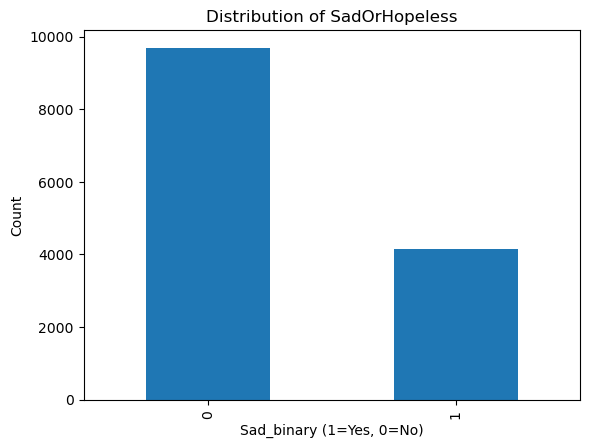

In [35]:
sad_counts.plot(kind="bar")
plt.title("Distribution of SadOrHopeless")
plt.xlabel("Sad_binary (1=Yes, 0=No)")
plt.ylabel("Count")

plt.savefig("../outputs/figures/sad_bar_chart.png")  # ⭐這行最重要
plt.show()

The bar chart shows that fewer students report feeling sad or hopeless compared to those who do not. Combined with the proportion result (approximately 0.30), this suggests that the observed proportion is close to the benchmark value, and there may not be a substantial difference. This will be formally tested in the inference stage.

## 3. EDA - BMIPCT
### 3-1 Summary Statistics of BMIPCT

In [36]:
bmi_df["BMIPCT"].describe()

count    1.306200e+04
mean     6.482068e+01
std      2.751676e+01
min      3.720000e-09
25%      4.516627e+01
50%      7.013853e+01
75%      8.945097e+01
max      9.993921e+01
Name: BMIPCT, dtype: float64

The summary statistics show that the BMI percentile has a mean around the mid-range, with a moderate spread between the lower and upper quartiles. This suggests variability in BMI levels among students, which will be further explored through visualization.

### 3-2 Histogram of BMIPCT

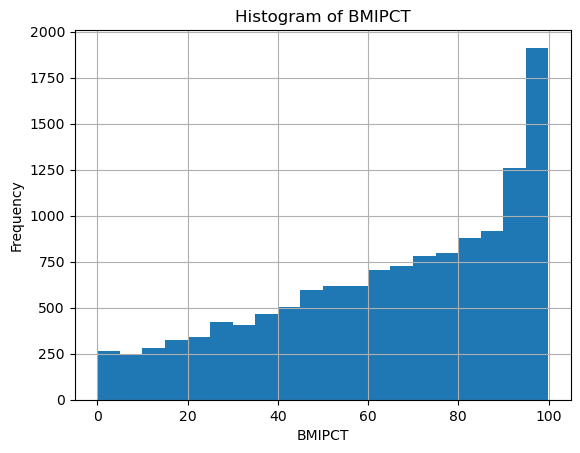

In [37]:
bmi_df["BMIPCT"].hist(bins=20)
plt.title("Histogram of BMIPCT")
plt.xlabel("BMIPCT")
plt.ylabel("Frequency")

plt.savefig("../outputs/figures/bmi_histogram.png")
plt.show()

The histogram suggests that the distribution of BMIPCT is left-skewed, with most observations concentrated at higher BMI percentile values and a long tail toward lower values. This indicates that lower BMI percentiles are relatively less common, and the skewness should be considered when interpreting the mean as a measure of central tendency.

### 3-3 Boxplot of BMIPCT

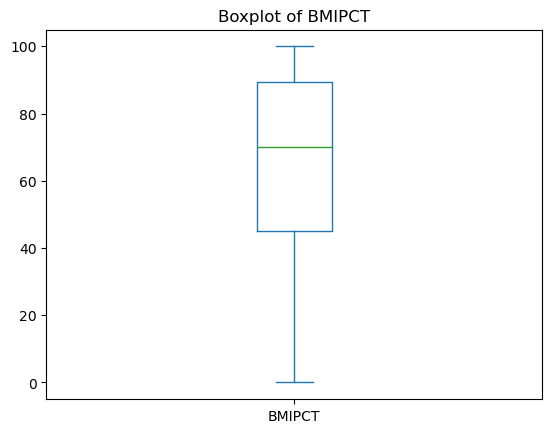

In [38]:
bmi_df["BMIPCT"].plot(kind="box")
plt.title("Boxplot of BMIPCT")

plt.savefig("../outputs/figures/bmi_boxplot.png")
plt.show()

The boxplot shows that BMIPCT has a wide spread, with the median located above the center of the distribution. There are no obvious extreme outliers observed, suggesting that the data is relatively consistent without unusually extreme values. However, the wide range indicates variability in BMI percentile among students.

## 4. Additional EDA

### 4-1 Create BMI Groups

In [39]:
joint_df["BMI_group"] = pd.qcut(joint_df["BMIPCT"], 3, labels=["Low", "Medium", "High"])

BMI percentile is divided into three groups (Low, Medium, High) to facilitate comparison of emotional outcomes across different BMI levels.

### 4-2 Proportion of SadOrHopeless by BMI Group

In [42]:
group_result = joint_df.groupby("BMI_group")["Sad_binary"].mean()
group_result

group_result.to_csv("../outputs/tables/bmi_group_summary.csv")

C:\Users\emma\AppData\Local\Temp\ipykernel_11536\88330964.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_result = joint_df.groupby("BMI_group")["Sad_binary"].mean()


The proportion of students feeling sad or hopeless increases slightly from the Low BMI group to the High BMI group. This suggests a possible positive relationship between BMI percentile and the likelihood of feeling sad or hopeless, although the difference appears to be relatively small.

### 4-3 Bar Chart of SadOrHopeless Proportion by BMI Group

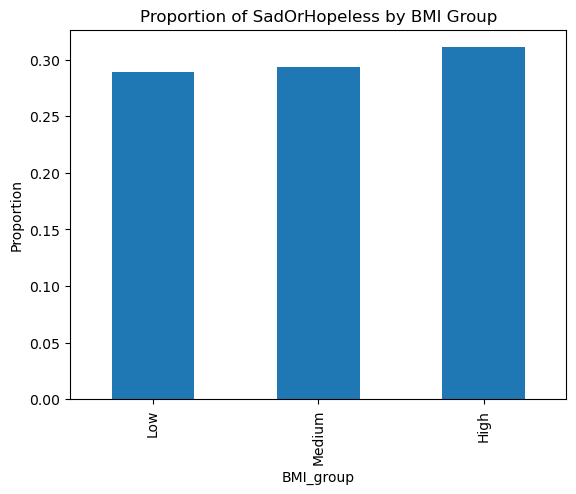

In [41]:
group_result.plot(kind="bar")
plt.title("Proportion of SadOrHopeless by BMI Group")
plt.ylabel("Proportion")

plt.savefig("../outputs/figures/bmi_group_bar.png")
plt.show()

The bar chart shows a slight increase in the proportion of students feeling sad or hopeless as BMI percentile increases from Low to High. This suggests a possible positive association between BMI percentile and emotional distress, although the differences appear to be relatively small. This relationship will be further examined in the inference stage.